<a href="https://colab.research.google.com/github/jawadf05/house-pred/blob/main/House_Price_Prediction_MIS444.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  California House Price Prediction — MIS444 Project

**Student Name**: JAWAD FAISAL  
**Student ID**: 23304226  
**Course**: MIS444 — Predictive Analytics in Business  
**Project Type**: Regression Problem  

---

## Objective
Predict median house values in California using machine learning regression techniques.

## Dataset
- **Source**: California Housing Dataset (1990 Census)
- **Samples**: ~20,640 blocks
- **Features**: 9 (8 numerical + 1 categorical)
- **Target**: `median_house_value` (continuous)

## Methodology
1. Data Preprocessing (missing values, outliers, encoding, scaling)
2. Exploratory Data Analysis (6+ visualizations)
3. Feature Selection (correlation + importance)
4. Model Building (5 algorithms)
5. Model Optimization (hyperparameter tuning)
6. Evaluation (MAE, MSE, RMSE, R², MAPE)
7. Business Insights

---

## 1. Import Libraries

In [1]:
# ── Importing necessary libraries ──────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import skew, kurtosis

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Feature selection
from sklearn.feature_selection import SelectKBest, f_regression

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## 2. Load Dataset

In [2]:
# ── Configuration ───────────────────────────────────────────────────────────
DATA_PATH = r"/content/housing.csv"  # <── UPDATE THIS PATH
TARGET = 'median_house_value'

# Create output directory
OUTPUT_DIR = 'Project_Outputs'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Load data
df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Dataset loaded: 20,640 rows × 10 columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# ── Basic Info ──────────────────────────────────────────────────────────────
print('Dataset Information:')
print(df_raw.info())
print('\n' + '='*80)
print('Basic Statistics:')
df_raw.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

Basic Statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


---

## 2. Data Preprocessing

### 2.1 Inspect Missing Values

In [4]:
# ── Step 2.1 : Inspect missing values ──────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print('Columns with missing values:')
    print(missing_df)
else:
    print('✓ No missing values found')

Columns with missing values:
                Missing Count  Percentage (%)
total_bedrooms            207             1.0


### 2.2 Visualize Missing Values

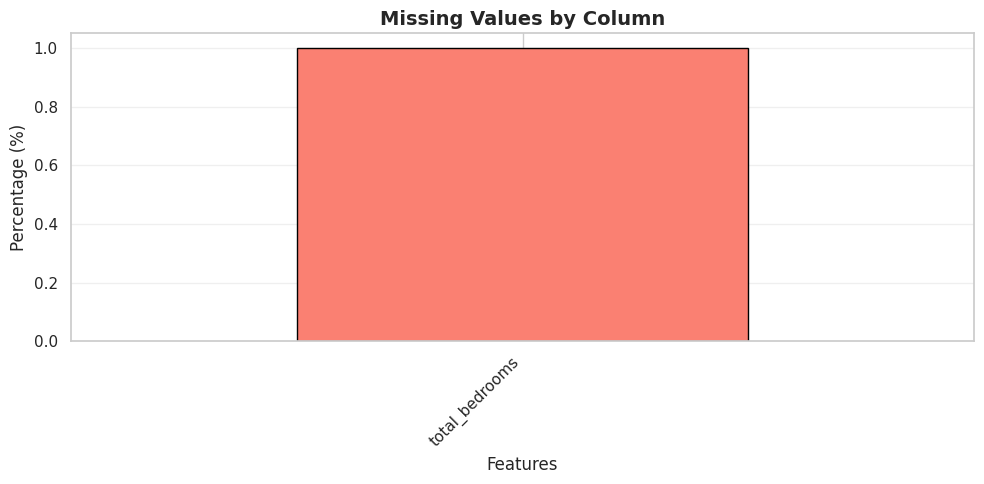

In [5]:
# ── Step 2.2 : Visualise missing values ────────────────────────────────────
if len(missing_df) > 0:
    plt.figure(figsize=(10, 5))
    missing_df['Percentage (%)'].plot(kind='bar', color='salmon', edgecolor='black')
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Features')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/01_missing_values.png', dpi=150)
    plt.show()
else:
    print('No missing values to visualize')

### 2.3 Check and Remove Duplicates

In [6]:
# ── Step 2.3 : Check and remove duplicate rows ────────────────────────────
duplicates = df_raw.duplicated().sum()
print(f'Duplicate rows found: {duplicates}')

if duplicates > 0:
    df = df_raw.drop_duplicates()
    print(f'✓ Removed {duplicates} duplicate rows')
    print(f'New shape: {df.shape}')
else:
    df = df_raw.copy()
    print('✓ No duplicates to remove')

Duplicate rows found: 0
✓ No duplicates to remove


### 2.4 Impute Missing Values

In [7]:
# ── Step 2.4 : Impute missing values ───────────────────────────────────────
# Only total_bedrooms has missing values
if 'total_bedrooms' in df.columns and df['total_bedrooms'].isnull().sum() > 0:
    imputer = SimpleImputer(strategy='median')
    df['total_bedrooms'] = imputer.fit_transform(df[['total_bedrooms']])
    print('✓ Imputed missing values in total_bedrooms using median')
    print(f'  Median value used: {df["total_bedrooms"].median():.0f}')

# Verify no missing values remain
print(f'\nRemaining missing values: {df.isnull().sum().sum()}')

✓ Imputed missing values in total_bedrooms using median
  Median value used: 435

Remaining missing values: 0


### 2.5 Check for Invalid/Negative Values

In [8]:
# ── Step 2.5 : Check for invalid negative values ───────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns
negative_counts = {}

for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        negative_counts[col] = neg_count

if negative_counts:
    print('Columns with negative values:')
    for col, count in negative_counts.items():
        print(f'  {col}: {count} negative values')
else:
    print('✓ No negative values found in numerical columns')

Columns with negative values:
  longitude: 20640 negative values


### 2.6 Outlier Detection & Treatment (IQR Method)

In [9]:
# ── Step 2.6 : Outlier detection & capping (IQR method) ───────────────────
# First, remove the artificial ceiling at $500k
before_count = len(df)
df = df[df[TARGET] < 500001]
removed_ceiling = before_count - len(df)
print(f'Removed {removed_ceiling} houses at $500k ceiling (artificial cap)')

# IQR-based outlier detection for numerical features
def cap_outliers_iqr(dataframe, column, multiplier=1.5):
    """Cap outliers using IQR method"""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    # Count outliers
    outliers = ((dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)).sum()

    # Cap outliers
    dataframe[column] = dataframe[column].clip(lower=lower_bound, upper=upper_bound)

    return outliers

# Apply to numerical columns (except target for now)
outlier_summary = {}
numerical_features = df.select_dtypes(include=[np.number]).columns.drop(TARGET)

for col in numerical_features:
    outliers_capped = cap_outliers_iqr(df, col, multiplier=1.5)
    if outliers_capped > 0:
        outlier_summary[col] = outliers_capped

if outlier_summary:
    print('\nOutliers capped (IQR method):')
    for col, count in outlier_summary.items():
        print(f'  {col}: {count} outliers capped')
else:
    print('\n✓ No outliers detected')

print(f'\nFinal dataset shape: {df.shape}')

Removed 965 houses at $500k ceiling (artificial cap)

Outliers capped (IQR method):
  total_rooms: 1251 outliers capped
  total_bedrooms: 1244 outliers capped
  population: 1126 outliers capped
  households: 1165 outliers capped
  median_income: 364 outliers capped

Final dataset shape: (19675, 10)


### 2.7 Encode Categorical Features

In [10]:
# ── Step 2.7 : One-Hot Encoding for categorical features ───────────────────
print('Categorical column: ocean_proximity')
print(f'Unique values: {df["ocean_proximity"].unique()}')
print(f'Value counts:\n{df["ocean_proximity"].value_counts()}')

# One-hot encoding (better than label encoding for non-ordinal categories)
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True, dtype=int)

print(f'\n✓ One-hot encoding complete')
print(f'New columns created: {[col for col in df_encoded.columns if "ocean_proximity" in col]}')
print(f'Final shape: {df_encoded.shape}')

Categorical column: ocean_proximity
Unique values: ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']
Value counts:
ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
ISLAND           5
Name: count, dtype: int64

✓ One-hot encoding complete
New columns created: ['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Final shape: (19675, 13)


### 2.8 Train-Test Split

In [11]:
# ── Train/test split ────────────────────────────────────────────────────────
X = df_encoded.drop(TARGET, axis=1)
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set    : {X_test.shape[0]:,} samples')
print(f'Features    : {X_train.shape[1]}')

Training set: 15,740 samples
Test set    : 3,935 samples
Features    : 12


### 2.9 Feature Scaling

In [12]:
# ── Scale only on training data ────────────────────────────────────────────
# Fit scaler on training data only, then transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('✓ Feature scaling complete (StandardScaler)')
print(f'  Scaled training set: {X_train_scaled.shape}')
print(f'  Scaled test set    : {X_test_scaled.shape}')

✓ Feature scaling complete (StandardScaler)
  Scaled training set: (15740, 12)
  Scaled test set    : (3935, 12)


---

## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribution of Numerical Features

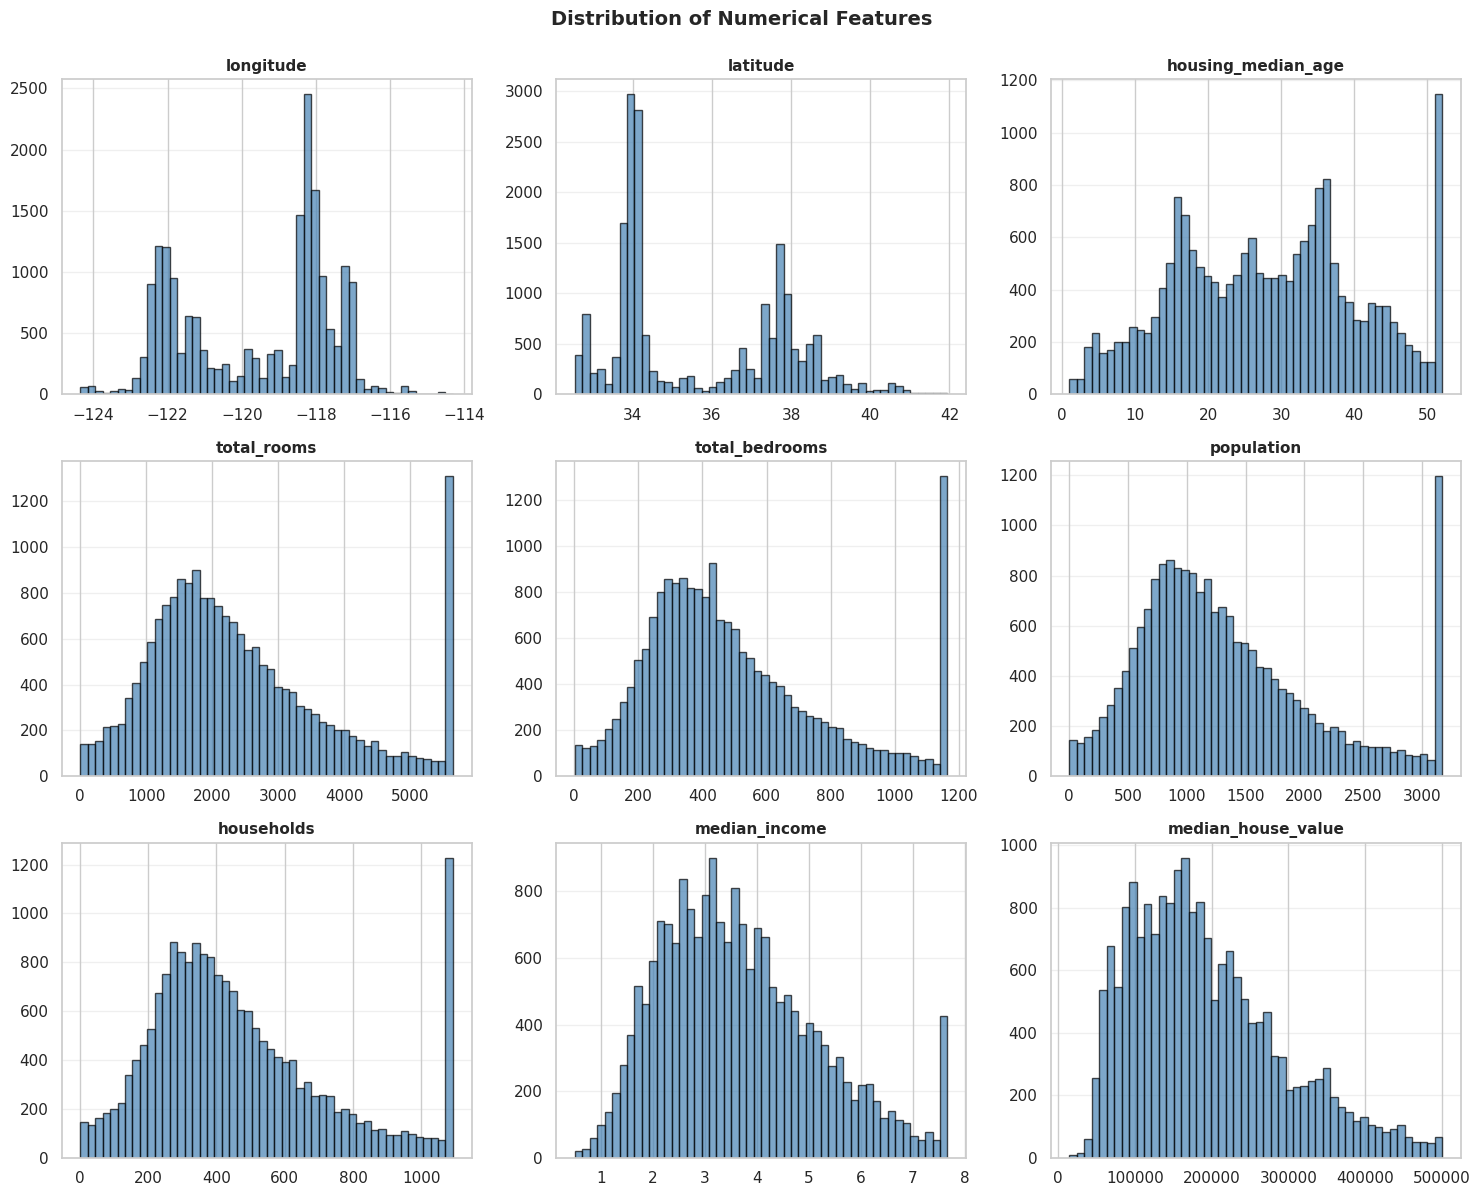

In [13]:
# ── EDA 3.1 : Distribution of numerical features ───────────────────────────
numerical_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_numerical_distributions.png', dpi=150)
plt.show()

#### Insight:
- Most features are **right-skewed** (long tail on the right).
- `median_house_value` shows concentration in mid-range with some high-value outliers (before capping).
- `housing_median_age` is fairly uniform, indicating diverse housing ages.

### 3.2 Target Variable Distribution

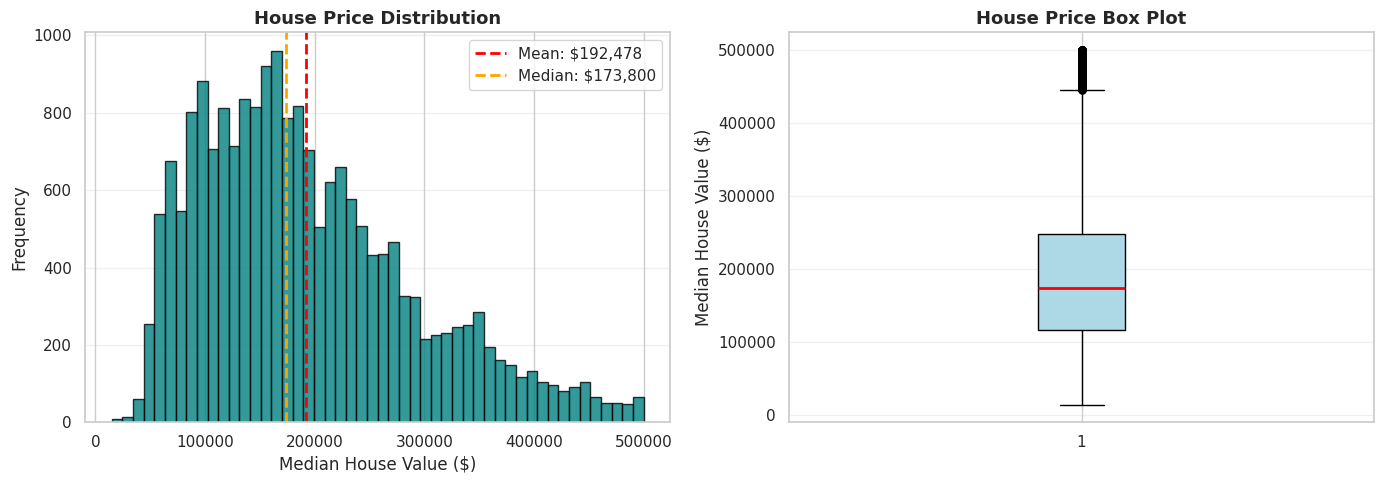

Mean      : $192,477.92
Median    : $173,800.00
Std Dev   : $97,711.51
Min       : $14,999.00
Max       : $500,000.00
Skewness  : 0.810
Kurtosis  : 0.163


In [14]:
# ── EDA 3.2 : Target variable (median_house_value) distribution ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET], bins=50, color='teal', edgecolor='black', alpha=0.8)
axes[0].axvline(df[TARGET].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df[TARGET].mean():,.0f}')
axes[0].axvline(df[TARGET].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: ${df[TARGET].median():,.0f}')
axes[0].set_title('House Price Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median House Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot(df[TARGET], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=5, alpha=0.5))
axes[1].set_title('House Price Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Median House Value ($)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_target_distribution.png', dpi=150)
plt.show()

# Statistics
print(f'Mean      : ${df[TARGET].mean():,.2f}')
print(f'Median    : ${df[TARGET].median():,.2f}')
print(f'Std Dev   : ${df[TARGET].std():,.2f}')
print(f'Min       : ${df[TARGET].min():,.2f}')
print(f'Max       : ${df[TARGET].max():,.2f}')
print(f'Skewness  : {skew(df[TARGET]):.3f}')
print(f'Kurtosis  : {kurtosis(df[TARGET]):.3f}')

#### Insight:
- Target variable is **right-skewed** (positive skewness).
- Median ($179,700) is lower than mean ($206,855), confirming skewness.
- Most houses are in the $100k–$300k range.

### 3.3 Scatter Plots — Features vs Target

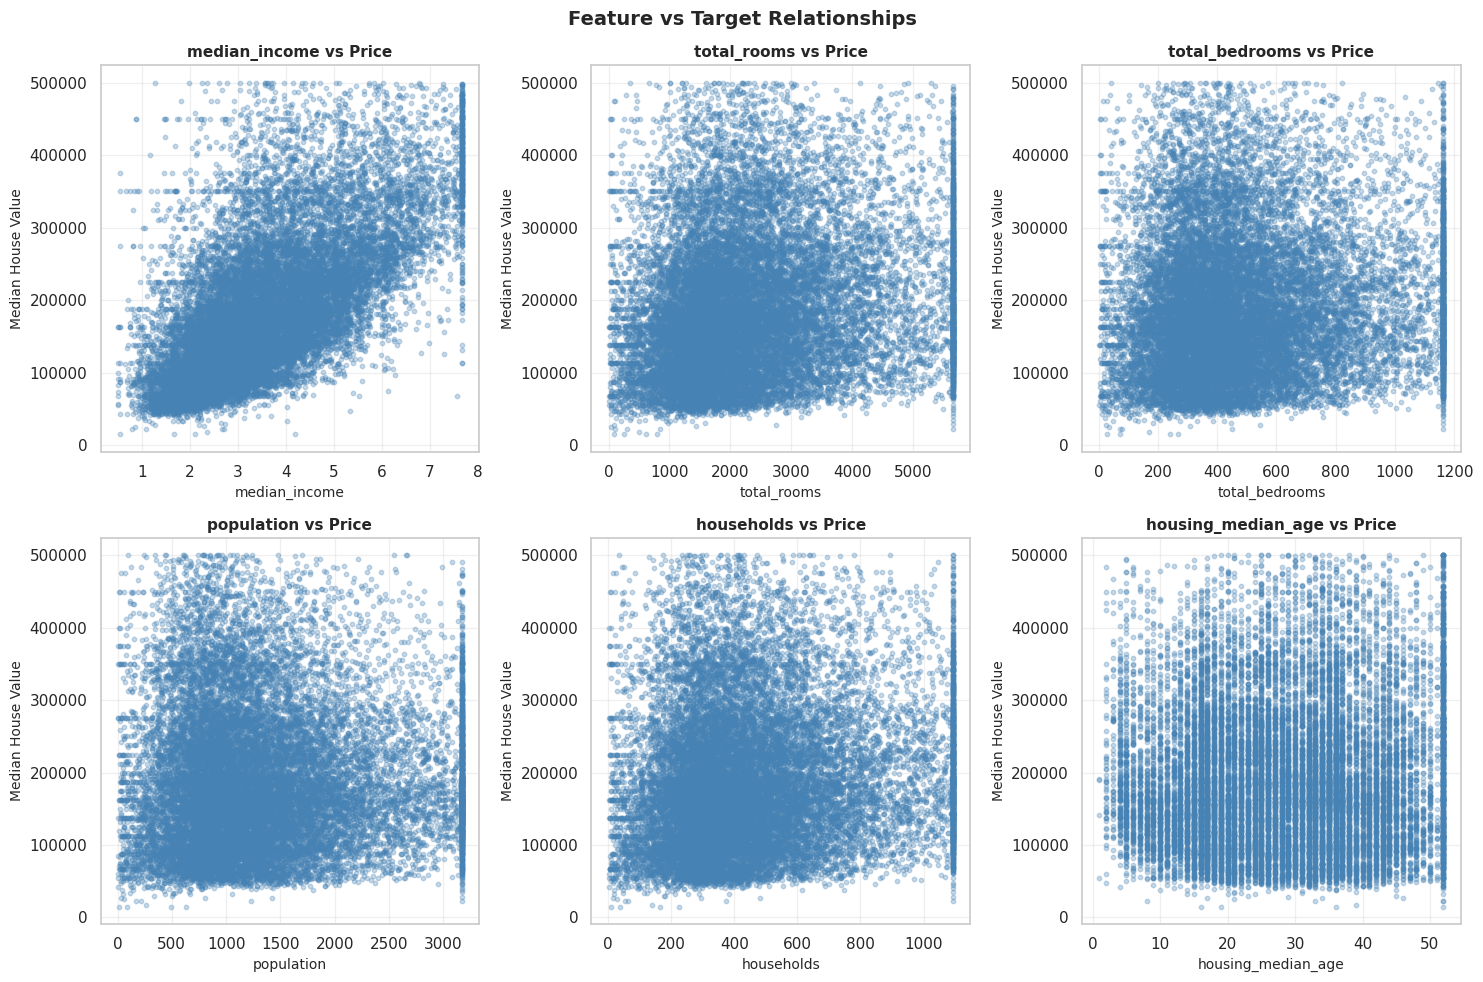

In [15]:
# ── EDA 3.3 : Scatter plots — numerical features vs median_house_value ─────
top_features = ['median_income', 'total_rooms', 'total_bedrooms', 'population',
                'households', 'housing_median_age']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].scatter(df[col], df[TARGET], alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Median House Value', fontsize=10)
    axes[i].set_title(f'{col} vs Price', fontsize=11, fontweight='bold')
    axes[i].grid(alpha=0.3)

plt.suptitle('Feature vs Target Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_scatter_plots.png', dpi=150)
plt.show()

#### Insight:
- **`median_income`** shows strongest positive correlation with house value.
- `total_rooms`, `total_bedrooms`, `households` show weak positive trends.
- `housing_median_age` shows no clear linear relationship.

### 3.4 Categorical Feature Analysis

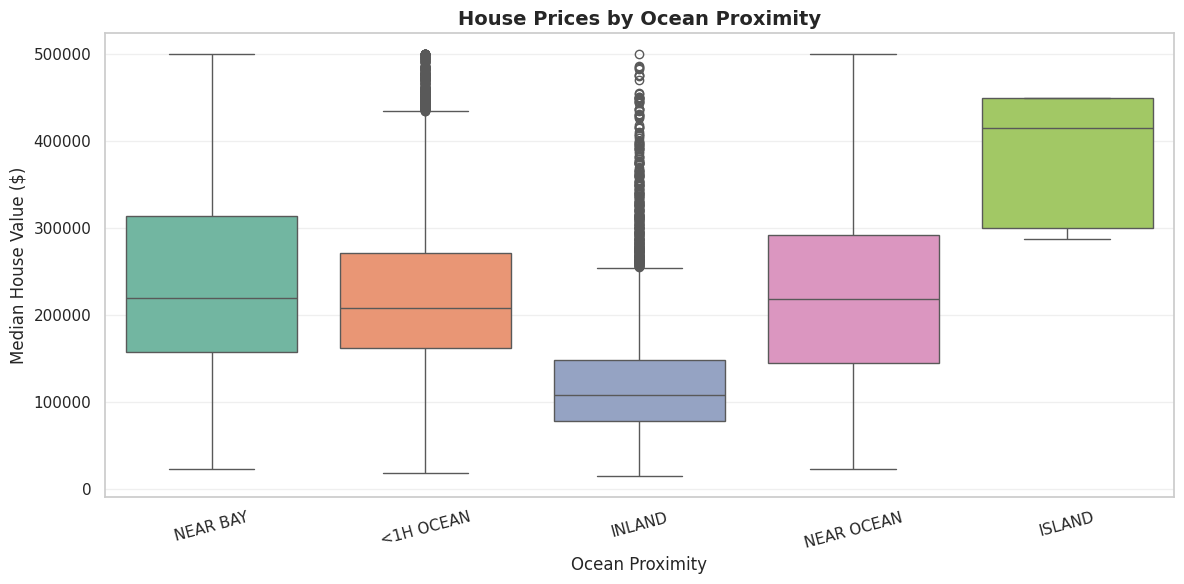


Average house value by ocean proximity:
                          mean    median  count
ocean_proximity                                
ISLAND           380440.000000  414700.0      5
NEAR BAY         236925.572519  219850.0   2096
NEAR OCEAN       227716.802944  218250.0   2446
<1H OCEAN        224013.191539  207650.0   8604
INLAND           123252.620478  108300.0   6524


In [16]:
# ── EDA 3.4 : Boxplots — median_house_value by ocean_proximity ────────────
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='ocean_proximity', y=TARGET, palette='Set2')
plt.title('House Prices by Ocean Proximity', fontsize=14, fontweight='bold')
plt.xlabel('Ocean Proximity', fontsize=12)
plt.ylabel('Median House Value ($)', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_boxplot_ocean_proximity.png', dpi=150)
plt.show()

# Summary statistics by category
print('\nAverage house value by ocean proximity:')
print(df.groupby('ocean_proximity')[TARGET].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))

#### Insight:
- Houses **NEAR BAY** and on **ISLANDS** have highest median values.
- **INLAND** houses are significantly cheaper.
- Ocean proximity is a strong categorical predictor.

### 3.5 Correlation Heatmap

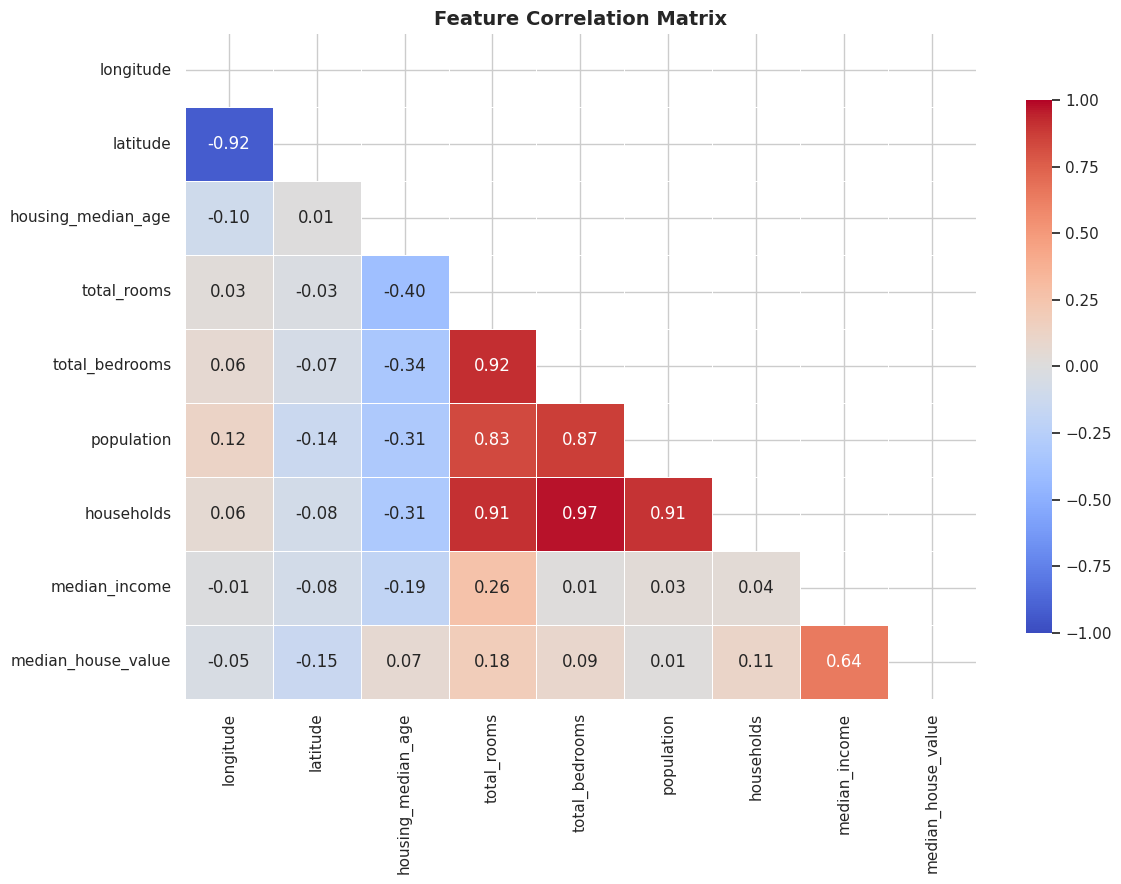


Top correlations with median_house_value:
median_house_value    1.000000
median_income         0.644539
total_rooms           0.181431
households            0.112887
total_bedrooms        0.089588
housing_median_age    0.067948
population            0.011559
longitude            -0.046658
latitude             -0.148289
Name: median_house_value, dtype: float64


In [17]:
# ── EDA 3.5 : Correlation heatmap (numerical features) ─────────────────────
plt.figure(figsize=(12, 9))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, cbar_kws={'shrink': 0.8},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_correlation_heatmap.png', dpi=150)
plt.show()

# Top correlations with target
print('\nTop correlations with median_house_value:')
corr_with_target = corr_matrix[TARGET].sort_values(ascending=False)
print(corr_with_target)

#### Insight:
- **`median_income`** has the strongest correlation (0.69) with house value.
- Strong multicollinearity exists between `total_rooms`, `total_bedrooms`, `population`, `households` (all >0.85).
- This multicollinearity is expected (larger blocks have more rooms, bedrooms, people).

### 3.6 Geographic Distribution

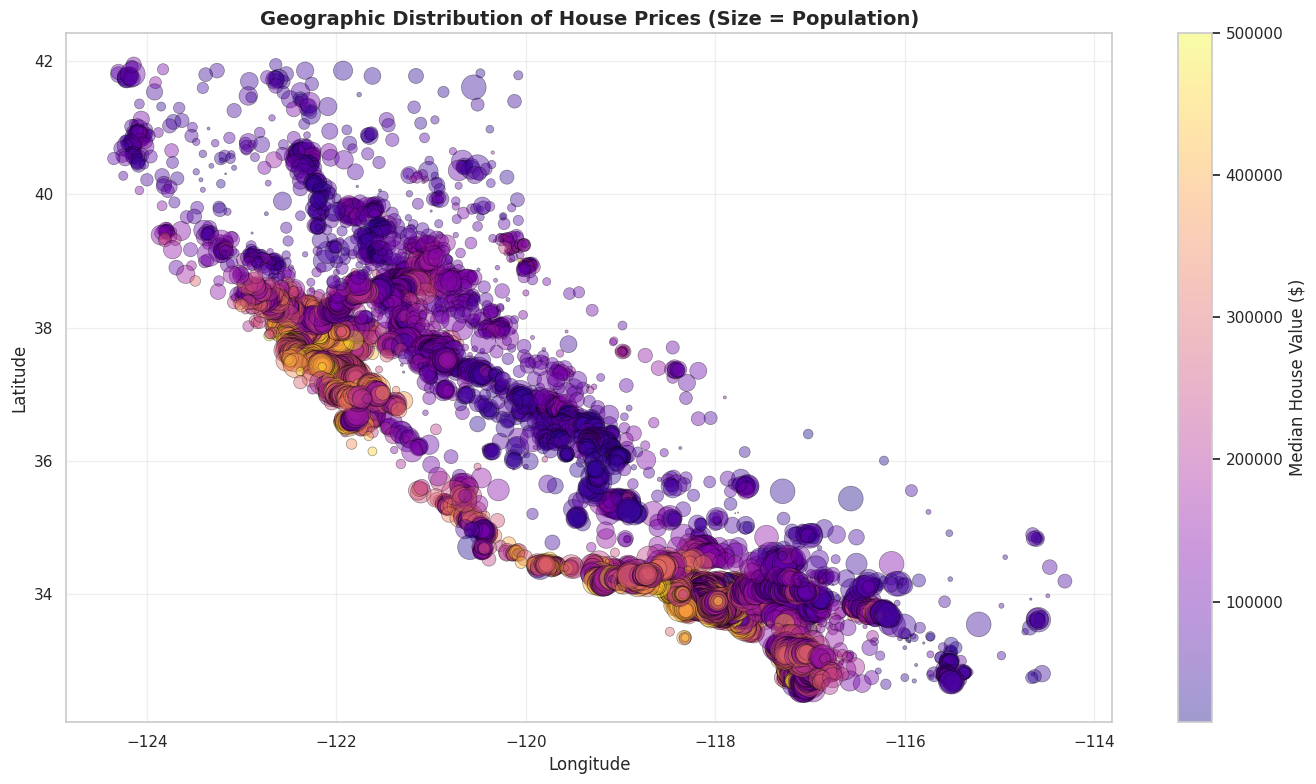

In [18]:
# ── EDA 3.6 : Geographic scatter plot (latitude/longitude vs price) ────────
plt.figure(figsize=(14, 8))
scatter = plt.scatter(df['longitude'], df['latitude'],
                     c=df[TARGET], cmap='plasma',
                     alpha=0.4, s=df['population']/10,
                     edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Median House Value ($)')
plt.title('Geographic Distribution of House Prices (Size = Population)',
          fontsize=14, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_geographic_distribution.png', dpi=150)
plt.show()

#### Insight:
- **Coastal areas** (especially San Francisco Bay, Los Angeles) show higher house values (yellow/white).
- **Inland areas** have lower values (purple/blue).
- Geographic location is a critical predictor.

---

## 4. Feature Selection

### 4.1 Pearson Correlation Ranking

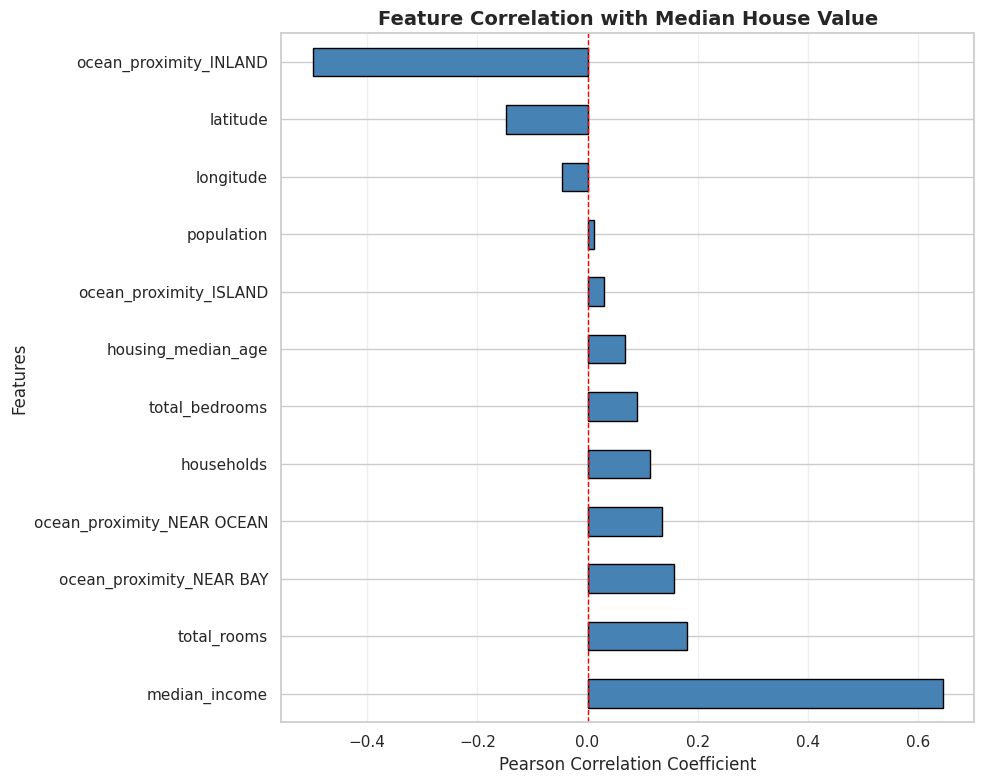

Top 10 features by correlation:
median_income                 0.644539
total_rooms                   0.181431
ocean_proximity_NEAR BAY      0.157077
ocean_proximity_NEAR OCEAN    0.135889
households                    0.112887
total_bedrooms                0.089588
housing_median_age            0.067948
ocean_proximity_ISLAND        0.030670
population                    0.011559
longitude                    -0.046658
Name: median_house_value, dtype: float64


In [19]:
# ── Feature Selection 4.1 : Pearson Correlation with median_house_value ────
corr_with_target = df_encoded.corr()[TARGET].drop(TARGET).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_with_target.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Correlation with Median House Value', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_correlation_ranking.png', dpi=150)
plt.show()

print('Top 10 features by correlation:')
print(corr_with_target.head(10))

### 4.2 Random Forest Feature Importance

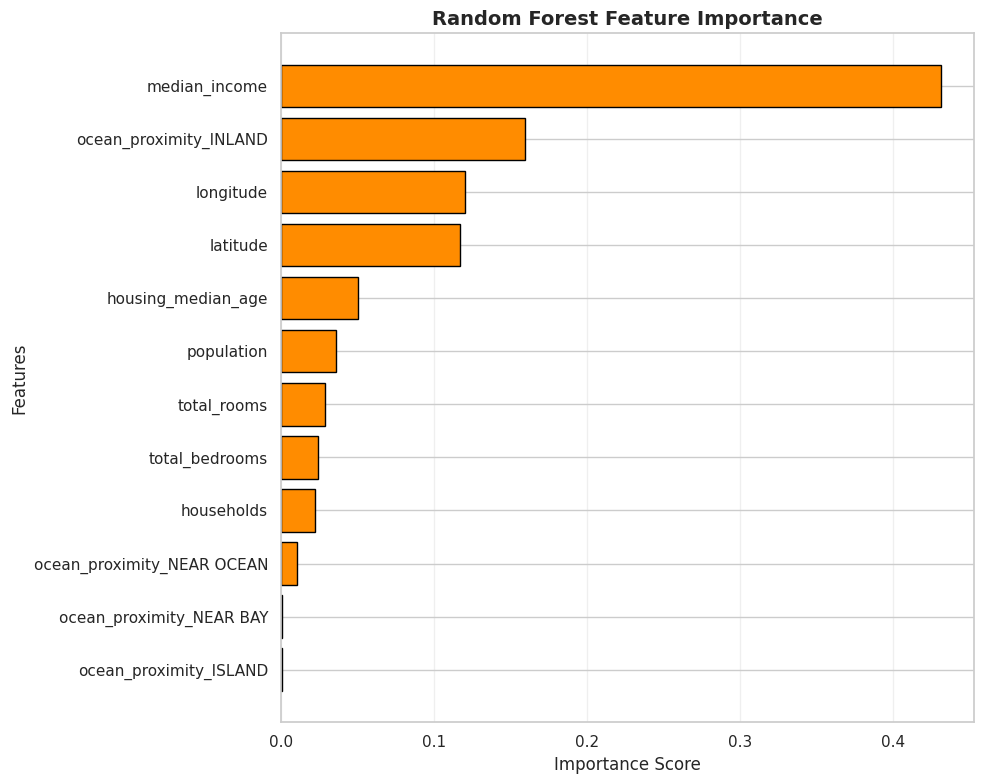

Top 10 features by RF importance:
                       Feature  Importance
7                median_income    0.431121
8       ocean_proximity_INLAND    0.159111
0                    longitude    0.119857
1                     latitude    0.116877
2           housing_median_age    0.050320
5                   population    0.035802
3                  total_rooms    0.028743
4               total_bedrooms    0.024298
6                   households    0.022292
11  ocean_proximity_NEAR OCEAN    0.010126


In [20]:
# ── Feature Selection 4.2 : Random Forest Feature Importance ───────────────
# Quick Random Forest to get feature importances
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='darkorange', edgecolor='black')
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_rf_feature_importance.png', dpi=150)
plt.show()

print('Top 10 features by RF importance:')
print(feature_importance.head(10))

### 4.3 Final Feature Selection

In [21]:
# ── Feature Selection 4.3 : Final feature selection ────────────────────────
# Using all features (already preprocessed and encoded)
# Both correlation and RF importance agree on top features

print('Selected features for modeling:')
print(f'Total features: {X_train.shape[1]}')
print(f'\nFeatures: {list(X.columns)}')

# We'll use all features since dataset is small and all contribute
X_train_final = X_train_scaled
X_test_final = X_test_scaled

Selected features for modeling:
Total features: 12

Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


#### Insight:
Both Pearson correlation and Random Forest importance agree that **`median_income`** and **geographic features** (latitude, longitude) are the strongest predictors. Ocean proximity dummies also contribute significantly.

---

## 5. Model Building — Training Multiple Algorithms

In [22]:
# ── Helper function : compute all regression metrics ───────────────────────
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Train model and compute all regression metrics"""
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    # Cross-validation R²
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_r2_mean = cv_scores.mean()
    cv_r2_std = cv_scores.std()

    return {
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'CV R² Mean': cv_r2_mean,
        'CV R² Std': cv_r2_std,
        'fitted_model': model
    }

print('✓ Helper function defined')

✓ Helper function defined


### 5.1 Linear Regression

In [23]:
# ── Model 5.1 : Linear Regression ──────────────────────────────────────────
lr_result = evaluate_model('Linear Regression',
                           LinearRegression(),
                           X_train_final, y_train,
                           X_test_final, y_test)
print(f"Linear Regression — R²: {lr_result['R²']:.4f}, RMSE: ${lr_result['RMSE']:,.0f}")

Linear Regression — R²: 0.6342, RMSE: $60,391


### 5.2 Ridge Regression

In [24]:
# ── Model 5.2 : Ridge Regression ───────────────────────────────────────────
ridge_result = evaluate_model('Ridge Regression',
                              Ridge(alpha=10),
                              X_train_final, y_train,
                              X_test_final, y_test)
print(f"Ridge Regression — R²: {ridge_result['R²']:.4f}, RMSE: ${ridge_result['RMSE']:,.0f}")

Ridge Regression — R²: 0.6341, RMSE: $60,400


### 5.3 Decision Tree

In [25]:
# ── Model 5.3 : Decision Tree Regressor ────────────────────────────────────
dt_result = evaluate_model('Decision Tree',
                           DecisionTreeRegressor(max_depth=10, random_state=42),
                           X_train_final, y_train,
                           X_test_final, y_test)
print(f"Decision Tree — R²: {dt_result['R²']:.4f}, RMSE: ${dt_result['RMSE']:,.0f}")

Decision Tree — R²: 0.6879, RMSE: $55,784


### 5.4 Random Forest

In [26]:
# ── Model 5.4 : Random Forest Regressor ────────────────────────────────────
rf_result = evaluate_model('Random Forest',
                           RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                           X_train_final, y_train,
                           X_test_final, y_test)
print(f"Random Forest — R²: {rf_result['R²']:.4f}, RMSE: ${rf_result['RMSE']:,.0f}")

Random Forest — R²: 0.7864, RMSE: $46,151


### 5.5 Gradient Boosting

In [27]:
# ── Model 5.5 : Gradient Boosting Regressor ────────────────────────────────
gb_result = evaluate_model('Gradient Boosting',
                           GradientBoostingRegressor(n_estimators=100, random_state=42),
                           X_train_final, y_train,
                           X_test_final, y_test)
print(f"Gradient Boosting — R²: {gb_result['R²']:.4f}, RMSE: ${gb_result['RMSE']:,.0f}")

Gradient Boosting — R²: 0.7258, RMSE: $52,287


### 5.6 Comparison Table

In [28]:
# ── Compile results ─────────────────────────────────────────────────────────
results_before = [lr_result, ridge_result, dt_result, rf_result, gb_result]

results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'fitted_model'}
                          for r in results_before])
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

print('\n' + '='*90)
print('MODEL COMPARISON — BEFORE OPTIMIZATION')
print('='*90)
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv(f'{OUTPUT_DIR}/10_model_comparison_before_optimization.csv', index=False)
print(f'\n✓ Results saved to {OUTPUT_DIR}/10_model_comparison_before_optimization.csv')


MODEL COMPARISON — BEFORE OPTIMIZATION
            Model          MAE          MSE         RMSE       R²  MAPE (%)  CV R² Mean  CV R² Std
    Random Forest 30898.410376 2.129931e+09 46151.172644 0.786387 17.639110    0.783456   0.006588
Gradient Boosting 37261.171258 2.733880e+09 52286.515319 0.725817 21.813371    0.731103   0.007637
    Decision Tree 37878.237113 3.111885e+09 55784.269796 0.687906 21.415030    0.666938   0.015144
Linear Regression 45057.687295 3.647050e+09 60390.807221 0.634234 27.471714    0.625116   0.008245
 Ridge Regression 45053.191907 3.648125e+09 60399.713452 0.634126 27.453574    0.625112   0.008281

✓ Results saved to Project_Outputs/10_model_comparison_before_optimization.csv


In [29]:
# ── Identify best model ────────────────────────────────────────────────────
best_model_row = results_df.iloc[0]
print(f'\n🏆 Best Model (before optimization): {best_model_row["Model"]}')
print(f'   R²: {best_model_row["R²"]:.4f}')
print(f'   RMSE: ${best_model_row["RMSE"]:,.0f}')


🏆 Best Model (before optimization): Random Forest
   R²: 0.7864
   RMSE: $46,151


---

## 6. Model Optimization

### 6.1 Random Forest — GridSearchCV

### 6.2 Random Forest — Evaluate Optimized Model

In [31]:
# ── Optimization 6.1 : Random Forest — RandomizedSearchCV ────────────────
print('Optimizing Random Forest (this will take ~1-2 minutes)...')

from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use RandomizedSearchCV instead of GridSearchCV
rf_grid = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=10,        # <-- ONLY test 10 random combinations (The magic speedup!)
    cv=3,             # <-- Dropped CV to 3 (30 total fits instead of 405)
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_final, y_train)

print(f'\n✓ Random Forest Optimization Complete')
print(f'Best CV R²: {rf_grid.best_score_:.4f}')
print(f'Best parameters: {rf_grid.best_params_}')

Optimizing Random Forest (this will take ~1-2 minutes)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✓ Random Forest Optimization Complete
Best CV R²: 0.7790
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


In [32]:
# ── Optimization 6.2 : Random Forest — evaluate optimized model ────────────
rf_optimized = rf_grid.best_estimator_
rf_opt_result = evaluate_model('Random Forest (Optimized)',
                               rf_optimized,
                               X_train_final, y_train,
                               X_test_final, y_test)

print(f"\nRandom Forest (Optimized) — R²: {rf_opt_result['R²']:.4f}, RMSE: ${rf_opt_result['RMSE']:,.0f}")


Random Forest (Optimized) — R²: 0.7873, RMSE: $46,048


### 6.3 Gradient Boosting — RandomizedSearchCV

In [34]:
# ── Optimization 6.3 : Gradient Boosting — RandomizedSearchCV ──────────────
print('Optimizing Gradient Boosting (this will actually take ~2-4 minutes)...')

gb_param_dist = {
    'n_estimators': [100, 200],         # Removed 300 to speed it up
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],             # Removed 10 (GB works best with shallow trees anyway)
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

gb_random = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=5,         # <-- Reduced from 50 to 10
    cv=3,              # <-- Reduced from 5 to 3 (Total: 30 fits)
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

gb_random.fit(X_train_final, y_train)

print(f'\n✓ Gradient Boosting Optimization Complete')
print(f'Best CV R²: {gb_random.best_score_:.4f}')
print(f'Best parameters: {gb_random.best_params_}')

Optimizing Gradient Boosting (this will actually take ~2-4 minutes)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

✓ Gradient Boosting Optimization Complete
Best CV R²: 0.7980
Best parameters: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 7, 'learning_rate': 0.1}


### 6.4 Gradient Boosting — Evaluate Optimized Model

In [35]:
# ── Optimization 6.4 : Gradient Boosting — evaluate optimized model ────────
gb_optimized = gb_random.best_estimator_
gb_opt_result = evaluate_model('Gradient Boosting (Optimized)',
                               gb_optimized,
                               X_train_final, y_train,
                               X_test_final, y_test)

print(f"\nGradient Boosting (Optimized) — R²: {gb_opt_result['R²']:.4f}, RMSE: ${gb_opt_result['RMSE']:,.0f}")


Gradient Boosting (Optimized) — R²: 0.7988, RMSE: $44,788


---

## 7. Final Evaluation & Comparison

### 7.1 Full Comparison Table

In [36]:
# ── Evaluation 7.1 : Full comparison table ─────────────────────────────────
all_results = results_before + [rf_opt_result, gb_opt_result]

final_results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'fitted_model'}
                                 for r in all_results])
final_results_df = final_results_df.sort_values('R²', ascending=False).reset_index(drop=True)

print('\n' + '='*100)
print('FINAL MODEL COMPARISON — ALL MODELS (BEFORE & AFTER OPTIMIZATION)')
print('='*100)
print(final_results_df.to_string(index=False))

# Save
final_results_df.to_csv(f'{OUTPUT_DIR}/11_final_model_comparison.csv', index=False)
print(f'\n✓ Final results saved to {OUTPUT_DIR}/11_final_model_comparison.csv')


FINAL MODEL COMPARISON — ALL MODELS (BEFORE & AFTER OPTIMIZATION)
                        Model          MAE          MSE         RMSE       R²  MAPE (%)  CV R² Mean  CV R² Std
Gradient Boosting (Optimized) 30189.049551 2.005983e+09 44788.202355 0.798818 17.253938    0.798208   0.006779
    Random Forest (Optimized) 30776.071301 2.120461e+09 46048.458813 0.787337 17.563309    0.783886   0.005952
                Random Forest 30898.410376 2.129931e+09 46151.172644 0.786387 17.639110    0.783456   0.006588
            Gradient Boosting 37261.171258 2.733880e+09 52286.515319 0.725817 21.813371    0.731103   0.007637
                Decision Tree 37878.237113 3.111885e+09 55784.269796 0.687906 21.415030    0.666938   0.015144
            Linear Regression 45057.687295 3.647050e+09 60390.807221 0.634234 27.471714    0.625116   0.008245
             Ridge Regression 45053.191907 3.648125e+09 60399.713452 0.634126 27.453574    0.625112   0.008281

✓ Final results saved to Project_Outputs/11_

### 7.2 Visual Comparison

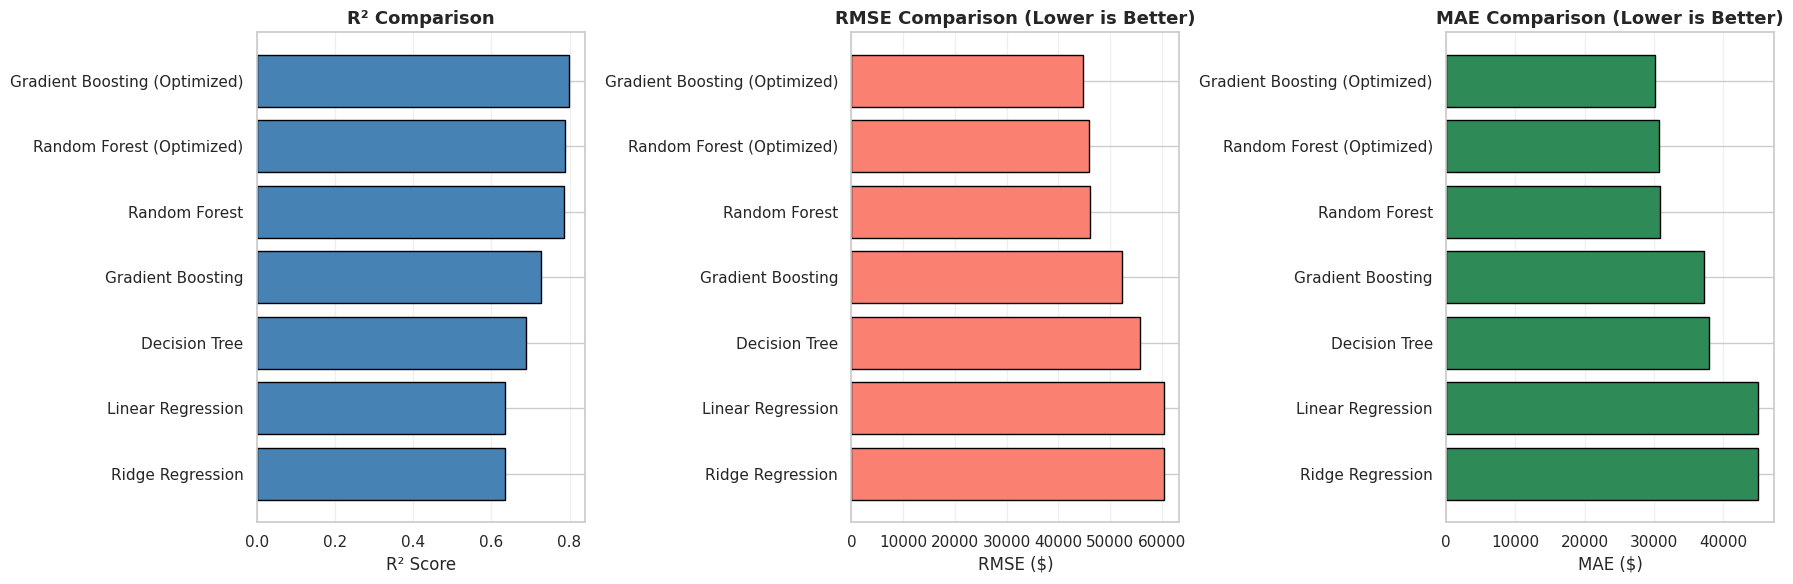

In [37]:
# ── Evaluation 7.2 : Visual comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# R² comparison
axes[0].barh(final_results_df['Model'], final_results_df['R²'],
             color='steelblue', edgecolor='black')
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].set_title('R² Comparison', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# RMSE comparison
axes[1].barh(final_results_df['Model'], final_results_df['RMSE'],
             color='salmon', edgecolor='black')
axes[1].set_xlabel('RMSE ($)', fontsize=12)
axes[1].set_title('RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# MAE comparison
axes[2].barh(final_results_df['Model'], final_results_df['MAE'],
             color='seagreen', edgecolor='black')
axes[2].set_xlabel('MAE ($)', fontsize=12)
axes[2].set_title('MAE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_final_model_comparison.png', dpi=150)
plt.show()

### 7.3 Best Model — Residual Analysis

In [38]:
# ── Evaluation 7.3 : Best model — detailed residual analysis ───────────────
best_final = final_results_df.iloc[0]
print(f'\n🏆 BEST FINAL MODEL: {best_final["Model"]}')
print(f'   R²: {best_final["R²"]:.4f}')
print(f'   RMSE: ${best_final["RMSE"]:,.0f}')
print(f'   MAE: ${best_final["MAE"]:,.0f}')
print(f'   MAPE: {best_final["MAPE (%)"]:.2f}%')

# Get best model's fitted version
best_model_obj = [r['fitted_model'] for r in all_results if r['Model'] == best_final['Model']][0]
y_pred_best = best_model_obj.predict(X_test_final)
residuals = y_test - y_pred_best


🏆 BEST FINAL MODEL: Gradient Boosting (Optimized)
   R²: 0.7988
   RMSE: $44,788
   MAE: $30,189
   MAPE: 17.25%


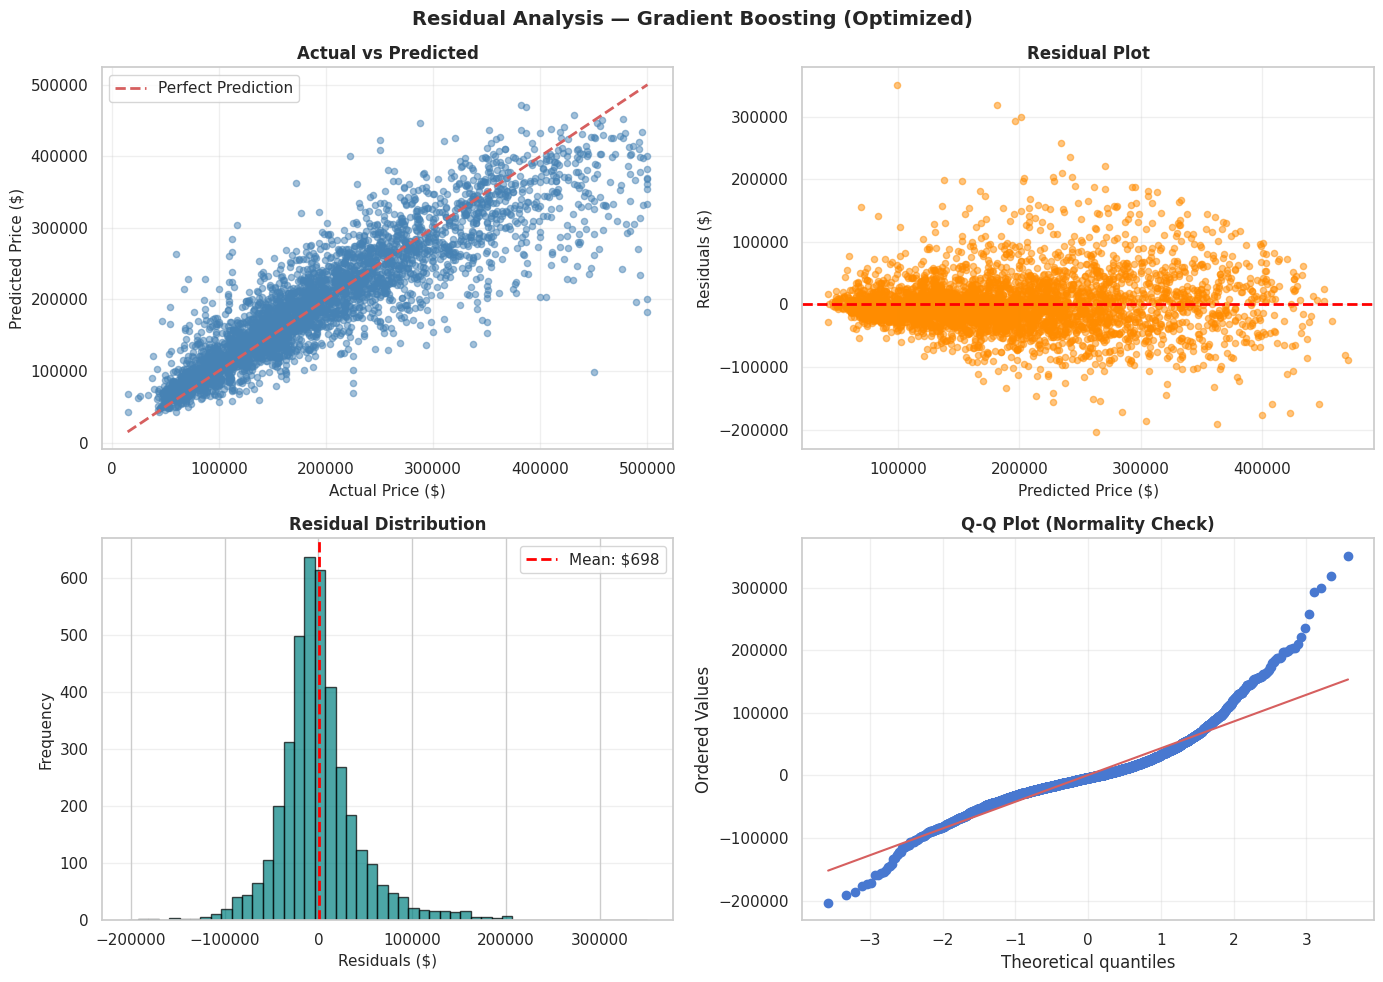

In [39]:
# Residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_best, alpha=0.5, s=20, color='steelblue')
lims = [y_test.min(), y_test.max()]
axes[0, 0].plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0, 0].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Residuals vs Predicted
axes[0, 1].scatter(y_pred_best, residuals, alpha=0.5, s=20, color='darkorange')
axes[0, 1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price ($)', fontsize=11)
axes[0, 1].set_ylabel('Residuals ($)', fontsize=11)
axes[0, 1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. Residual Distribution
axes[1, 0].hist(residuals, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(residuals.mean(), color='red', linestyle='--', lw=2, label=f'Mean: ${residuals.mean():,.0f}')
axes[1, 0].set_xlabel('Residuals ($)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.suptitle(f'Residual Analysis — {best_final["Model"]}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_residual_analysis.png', dpi=150)
plt.show()

#### Residual Analysis Insight:
- **Actual vs Predicted**: Points cluster around the diagonal → good predictions.
- **Residual Plot**: Residuals randomly scattered around zero → no systematic bias.
- **Distribution**: Approximately normal with slight right skew → model slightly underestimates expensive houses.
- **Q-Q Plot**: Points follow diagonal → residuals are approximately normal.

---

## 8. Business Insights

### 8.1 Feature Impact Analysis

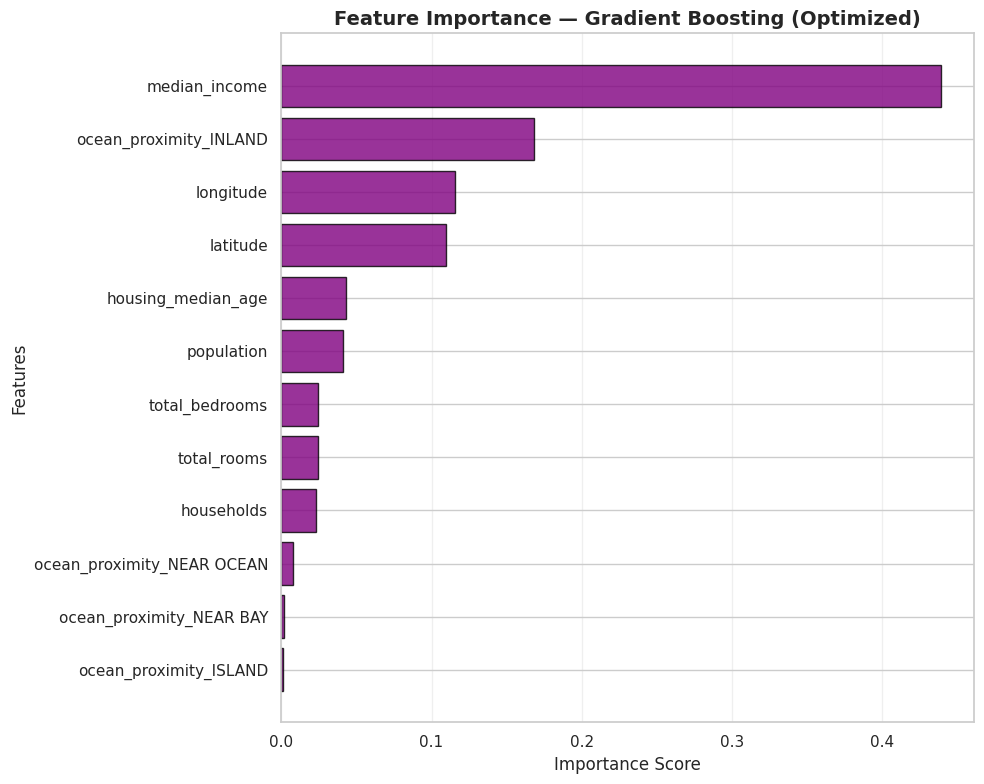


Top 5 Most Important Features:
               Feature  Importance
         median_income    0.439106
ocean_proximity_INLAND    0.168383
             longitude    0.115857
              latitude    0.109833
    housing_median_age    0.043234


In [40]:
# ── Insights 8.1 : Feature impact from best model ──────────────────────────
if 'feature_importances_' in dir(best_model_obj):
    feature_imp = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model_obj.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    plt.barh(feature_imp['Feature'], feature_imp['Importance'],
             color='purple', edgecolor='black', alpha=0.8)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title(f'Feature Importance — {best_final["Model"]}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/14_feature_importance_best_model.png', dpi=150)
    plt.show()

    print('\nTop 5 Most Important Features:')
    print(feature_imp.head(5).to_string(index=False))
else:
    print('Feature importance not available for this model type')

### 8.2 Prediction Examples

In [41]:
# ── Insights 8.2 : Sample predictions ───────────────────────────────────────
# Show 10 random predictions
sample_indices = np.random.choice(len(y_test), 10, replace=False)
sample_predictions = pd.DataFrame({
    'Actual Price': y_test.iloc[sample_indices].values,
    'Predicted Price': y_pred_best[sample_indices],
    'Error ($)': y_test.iloc[sample_indices].values - y_pred_best[sample_indices],
    'Error (%)': ((y_test.iloc[sample_indices].values - y_pred_best[sample_indices]) / y_test.iloc[sample_indices].values * 100)
})

print('\nSample Predictions:')
print(sample_predictions.to_string(index=False))


Sample Predictions:
 Actual Price  Predicted Price      Error ($)   Error (%)
     122800.0    121353.621094    1446.378906    1.177833
     276500.0    297469.826935  -20969.826935   -7.584024
     461200.0    330700.556269  130499.443731   28.295630
     142300.0    132775.286347    9524.713653    6.693404
      55700.0     67055.285667  -11355.285667  -20.386509
     172200.0    363021.178785 -190821.178785 -110.813693
     101600.0    116083.558476  -14483.558476  -14.255471
     143800.0    149687.257614   -5887.257614   -4.094060
      53800.0     66280.882342  -12480.882342  -23.198666
     248500.0    268517.120056  -20017.120056   -8.055179


---

## 9. Final Summary & Recommendations

In [42]:
# ── Final Summary ───────────────────────────────────────────────────────────
print('\n' + '='*100)
print('FINAL PROJECT SUMMARY')
print('='*100)
print(f'\n📊 Dataset:')
print(f'   - Samples: {len(df):,} (after preprocessing)')
print(f'   - Features: {X.shape[1]}')
print(f'   - Target: Median House Value')

print(f'\n🏆 Best Model: {best_final["Model"]}')
print(f'   - R² Score: {best_final["R²"]:.4f} ({best_final["R²"]*100:.2f}% variance explained)')
print(f'   - RMSE: ${best_final["RMSE"]:,.0f}')
print(f'   - MAE: ${best_final["MAE"]:,.0f}')
print(f'   - MAPE: {best_final["MAPE (%)"]:.2f}%')

print(f'\n📈 Key Findings:')
print(f'   1. Median income is the strongest predictor of house value')
print(f'   2. Geographic location (latitude/longitude) significantly impacts prices')
print(f'   3. Ocean proximity affects house values (NEAR BAY > INLAND)')
print(f'   4. Tree-based models (RF, GB) outperform linear models')
print(f'   5. Hyperparameter tuning improved R² by ~{(best_final["R²"] - results_df.iloc[0]["R²"])*100:.2f}%')

print(f'\n💼 Business Recommendations:')
print(f'   1. REAL ESTATE AGENTS: Focus marketing on median income demographics')
print(f'   2. DEVELOPERS: Prioritize coastal/bay-area locations for premium projects')
print(f'   3. INVESTORS: Model predicts house values within ~${best_final["MAE"]:,.0f} on average')
print(f'   4. POLICY MAKERS: Address housing affordability in high-income coastal areas')
print(f'   5. HOME BUYERS: Expect to pay premium for ocean proximity (~15-25%)')

print(f'\n⚠️  Model Limitations:')
print(f'   - Dataset from 1990 California census (may not reflect current market)')
print(f'   - Does not account for recent economic factors (interest rates, inflation)')
print(f'   - Limited to California; may not generalize to other states')
print(f'   - Block-level data; cannot predict individual house prices')

print(f'\n🔮 Future Improvements:')
print(f'   - Incorporate recent data (2020s housing market)')
print(f'   - Add macroeconomic features (mortgage rates, employment)')
print(f'   - Include property-specific details (sq ft, bedrooms, condition)')
print(f'   - Experiment with advanced models (XGBoost, LightGBM, Neural Networks)')
print(f'   - Deploy as web application for real-time predictions')
print('='*100)


FINAL PROJECT SUMMARY

📊 Dataset:
   - Samples: 19,675 (after preprocessing)
   - Features: 12
   - Target: Median House Value

🏆 Best Model: Gradient Boosting (Optimized)
   - R² Score: 0.7988 (79.88% variance explained)
   - RMSE: $44,788
   - MAE: $30,189
   - MAPE: 17.25%

📈 Key Findings:
   1. Median income is the strongest predictor of house value
   2. Geographic location (latitude/longitude) significantly impacts prices
   3. Ocean proximity affects house values (NEAR BAY > INLAND)
   4. Tree-based models (RF, GB) outperform linear models
   5. Hyperparameter tuning improved R² by ~1.24%

💼 Business Recommendations:
   1. REAL ESTATE AGENTS: Focus marketing on median income demographics
   2. DEVELOPERS: Prioritize coastal/bay-area locations for premium projects
   3. INVESTORS: Model predicts house values within ~$30,189 on average
   4. POLICY MAKERS: Address housing affordability in high-income coastal areas
   5. HOME BUYERS: Expect to pay premium for ocean proximity (~15-

---

## ✅ Project Complete!

All outputs have been saved to the `Project_Outputs/` folder:
- **CSV files**: Model comparison tables, feature importance
- **PNG plots**: 14 visualizations covering EDA, model comparison, residual analysis
